# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
Already up to date.


## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas
%pip install keras-tuner

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, Add, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras_tuner as kt

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE
from tools.feature_selection import (
    get_feature_importance,
    plot_feature_importance_comparison,
    perm_importance,
    plot_perm_importance_comparison,
    rfe_importance,
    plot_rfe_importance)
from tools.distribution import plot_target_var_distribution
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

## Import Datasets

Here we will import our version 1 of our datasets and we will also combine the buffer zone datasets into one.

>NOTE: we did not use version 2 of our dataset since it showed little to none improvement in our mixed buffer zone RandomForestRegressor model. The energy variables were also not that important in that model.

In [4]:
train_combined, test_combined = combine_buffer_datasets('data/train', 'data/test')

Loading training data: data/train/50m_buffer_dataset.csv
Loading test data: data/test/50m_buffer_test_dataset.csv
Loading training data: data/train/100m_buffer_dataset.csv
Loading test data: data/test/100m_buffer_test_dataset.csv
Loading training data: data/train/150m_buffer_dataset.csv
Loading test data: data/test/150m_buffer_test_dataset.csv
Loading training data: data/train/300m_buffer_dataset.csv
Loading test data: data/test/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 77)
Final Test Dataset Shape: (1040, 78)


In [5]:
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined)


Final Processed Training Dataset Shape: (11229, 200)
Final Processed Testing Dataset Shape: (1040, 201)


# Mixed Buffers Neural Network

This notebook is for creating a neural network model with a mixture of buffer zones. For details on the train/test dataset refer to our past notebooks:
- [01_dataset_generation](/01_dataset_generation.ipynb)
- [02_more_dataset_generation](/02_more_dataset_generation.ipynb)

## Preprocessing

First, we will seperate the target variable and scale the data.

In [6]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

#scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SPLIT, random_state=RANDOM_STATE
)

#make into df
x_train_df = pd.DataFrame(X_train, columns=X.columns)
x_valid_df = pd.DataFrame(X_valid, columns=X.columns)

## Feature Selection

Next, we will do feature selection. We now have interaction terms and a mixture of variables in different buffer zone measurements, so the dataset is filled with a lot of features that need to be dropped. We will use a RandomForestRegressor for this.

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

In [7]:
# save the selected features so we don't have to run again
selected_feature_names=['50m_1NPCRI', '100m_Elevation_Wind_X', '150m_Traffic_Volume',
                        '150m_Elevation_Wind_Y', '150m_Humidity_NDVI', '150m_Traffic_NDBI',
                        '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol', '300m_Total_Building_Area_m2',
                        '300m_Building_Construction_Year', '300m_Ground_Elevation', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_TotalBuildingArea_NDVI', '300m_Traffic_NDVI', '300m_Traffic_NDBI',
                        '300m_Building_Aspect_Ratio', '300m_Sky_View_Factor', '300m_Canopy_Cover_Ratio',
                        '300m_GHG_Proxy']

Here we see the features that were selected. These features maximized the cross-validation score. Now let's select them for our training/validation set.

In [8]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

Now that we have the selected features, let's re do the scaler so that the saved scaler only accepts the selected features.

In [9]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

# only selected
X = X[selected_feature_names]

#scaler
scaler = StandardScaler()
scaler.fit_transform(X)

array([[ 1.39967056,  0.09472103, -0.40001901, ...,  0.05087589,
        -0.1644388 , -0.3086262 ],
       [ 1.40543401,  0.09472103, -0.40001901, ...,  0.06567736,
        -0.16443872, -0.32488767],
       [ 1.37011591,  0.09829482, -0.40001901, ...,  0.09243028,
        -0.16443854, -0.31404669],
       ...,
       [-3.46550134, -0.809448  ,  0.29181684, ...,  2.61502334,
         6.36022495, -0.70974256],
       [-3.41902133, -0.809448  ,  0.29181684, ...,  2.61502334,
         6.36349871, -0.70974256],
       [-3.39757546, -0.809448  ,  0.29181684, ...,  2.61502334,
         6.3687642 , -0.70974256]])

## Building The Neural Network

We tried many architectures, but our most succesful one was a [Residual Network (ResNet)](https://www.geeksforgeeks.org/residual-networks-resnet-deep-learning/). We utilized `keras-tuner` to decide on our dropout rate, neurons, and learning rate. The layers were decided based on how well our model generalized when adding the layers.

We tried many neural network architectures, but our most successful one was a [Residual Network (ResNet)](https://www.geeksforgeeks.org/residual-networks-resnet-deep-learning/) for predicting UHI. ResNet’s skip connections helped mitigate the vanishing gradient problem, allowing us to train a deeper model effectively. The network demonstrated superior performance in capturing spatial patterns related to urban heat islands, outperforming other architectures in terms of accuracy and generalization.

In [10]:
# get model, skip if the model does not exist
model_file = 'models/mixed_buffers_ResNet/mixed_buffers_ResNet_model.keras'
if os.path.exists(model_file):
  resnet_model = load_model(model_file)

>NOTE: If you already have the model you can load it into the notebook instead of running the training again

In [10]:
def build_uhi_model(input_shape):
    """
    This function builds our ResNet UHI model.

    Inputs:
      input_shape: the shape of the input data

    Outputs:
      model: the ResNet model
    """
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(1000, activation='relu')(input_layer)
    x = Dropout(0.2)(x)

    # First Residual Block
    x_shortcut = Dense(800, activation='relu')(x)  # Shortcut path
    x = Dense(800, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(600, activation='relu')(x)  # Shortcut path
    x = Dense(600, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(500, activation='relu')(x)  # Shortcut path
    x = Dense(500, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # Second Residual Block
    x_shortcut = Dense(300, activation='relu')(x)
    x = Dense(300, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block
    x_shortcut = Dense(200, activation='relu')(x)
    x = Dense(200, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Fourth Residual Block
    x_shortcut = Dense(50, activation='relu')(x)
    x = Dense(50, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Use a Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0005,
        decay_steps=10000,
        decay_rate=0.9
    )

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

Now, that we found a successful model architecture let's train it.

In [11]:
# Retrain model with selected features
resnet_model = build_uhi_model(x_train_selected.shape[1])

# Callbacks: Early Stopping (Monitor Val MAE) & Model Checkpoint
early_stopping = EarlyStopping(
    monitor='val_mae',    # Monitor validation MAE
    patience=20,          # Stop if no improvement for 20 epochs
    restore_best_weights=True,  # Load the best model after stopping
    mode='min'            # Minimize validation MAE
)

history = resnet_model.fit(
    x_train_selected, y_train,
    validation_data=(x_valid_selected, y_valid),
    epochs=300,  # Adjust based on convergence
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 0.3934 - mae: 0.3804 - mse: 0.3934 - val_loss: 0.0215 - val_mae: 0.1305 - val_mse: 0.0215
Epoch 2/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0210 - mae: 0.0914 - mse: 0.0210 - val_loss: 0.0017 - val_mae: 0.0309 - val_mse: 0.0017
Epoch 3/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0071 - mae: 0.0552 - mse: 0.0071 - val_loss: 0.0021 - val_mae: 0.0303 - val_mse: 0.0021
Epoch 4/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0067 - mae: 0.0526 - mse: 0.0067 - val_loss: 0.0025 - val_mae: 0.0369 - val_mse: 0.0025
Epoch 5/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0072 - mae: 0.0425 - mse: 0.0072 - val_loss: 0.0010 - val_mae: 0.0189 - val_mse: 0.0010
Epoch 6/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0361 - mae: 0.0682 - mse: 0.0361 - val_loss: 4.6632e-04 - val_mae: 0.0182 - val_mse: 4.6632e-04
Epoch 7/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - mae: 0.0194 - 

Now that the model is trained, lets see its learning curve.

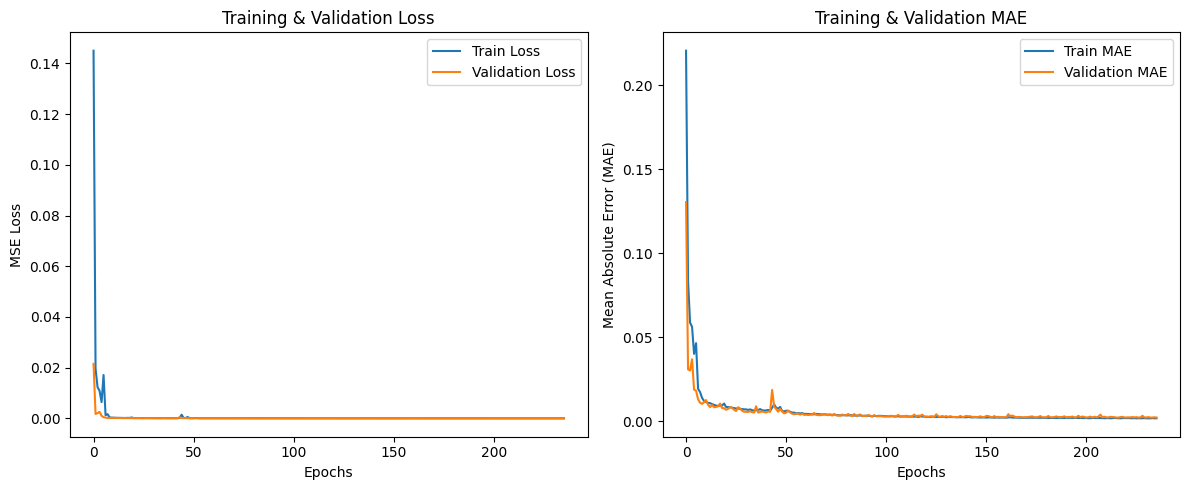

In [12]:
# Plot Learning Curves
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training & Validation MAE')
plt.legend()

plt.tight_layout()
plt.show()

1. **Left Plot - Training & Validation Loss (MSE Loss)**
   - The Mean Squared Error (MSE) loss starts high and rapidly decreases within the first few epochs.
   - After around 25 epochs, both the training and validation losses stabilize near zero.
   - The very small loss values indicate that the model has learned the task effectively.
   - The small spike around epoch 50 suggests a minor instability but is quickly corrected.
   - The training and validation losses are closely aligned, indicating minimal overfitting.

2. **Right Plot - Training & Validation MAE**
   - The Mean Absolute Error (MAE) follows a similar pattern, starting high and rapidly dropping.
   - Both training and validation MAE stabilize around zero, suggesting good predictive performance.
   - There is a small fluctuation around epoch 50, mirroring the behavior in the loss plot.
   - The near-identical curves for training and validation MAE further confirm that the model generalizes well.

3. **Overall Analysis**
  - The model appears to be well-trained, with both loss and error decreasing significantly early on and stabilizing.
  - No major overfitting is observed as training and validation curves remain close.
  - The small spike around epoch 50 suggests a momentary instability, possibly due to learning rate adjustments.

## In-Sample Evaluation

In [11]:
# Make predictions on the training data
insample_predictions = resnet_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
In-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9853446118374067


## Out-Sample Evaluation

In [12]:
# Make predictions on the validation data
outsample_predictions = resnet_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffer zone R-squared: {outsample_r2}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Out-Sample Evaluation:
  Mixed buffer zone R-squared: 0.9625555702336237


# Challenge Submission

We will now submit our `ResNet` model to the challenge.
>NOTE: We can have multiple submissions.

In [13]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

#select features
test_dataset = test_dataset[selected_feature_names]

#scale
x_test = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index).values

# Model prediction
test_predictions = resnet_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions.flatten()
})
submission_df

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.962562
1,-73.971928,40.788875,0.962974
2,-73.967080,40.789080,0.962524
3,-73.972550,40.789082,0.960741
4,-73.969697,40.787953,0.959975
...,...,...,...
1035,-73.919388,40.813803,1.041966
1036,-73.931033,40.833178,1.042899
1037,-73.934647,40.854542,1.039280
1038,-73.917223,40.815413,1.037447


Save the submission dataframe to submit into challenge portal:

In [14]:
submission_df.to_csv("mixed_buffers_ResNet_model_submission.csv", index=False)

Score We Received:

![submission score](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/mixed_buffers_ResNet_model_score.jpeg?raw=1)

Our ResNet model did slightly worse than our Mixed Buffer RandomForestRegressor.

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

In [14]:
# Initialize SHAP Explainer for keras model
explainer = Explainer(
    model=resnet_model,
    explainer_type=shap.DeepExplainer,
    X=test_dataset,
    feature_names=test_dataset.columns,
    ref_data=test_dataset
)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

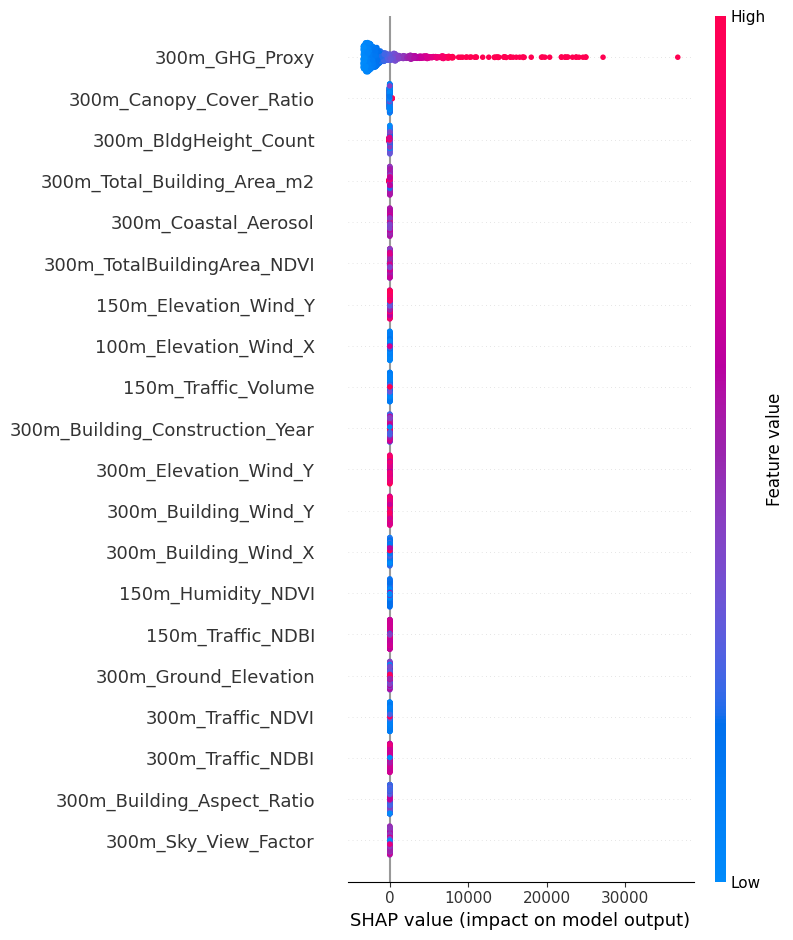

In [15]:
explainer.summary_plot()

>TODO

## Bar Plot

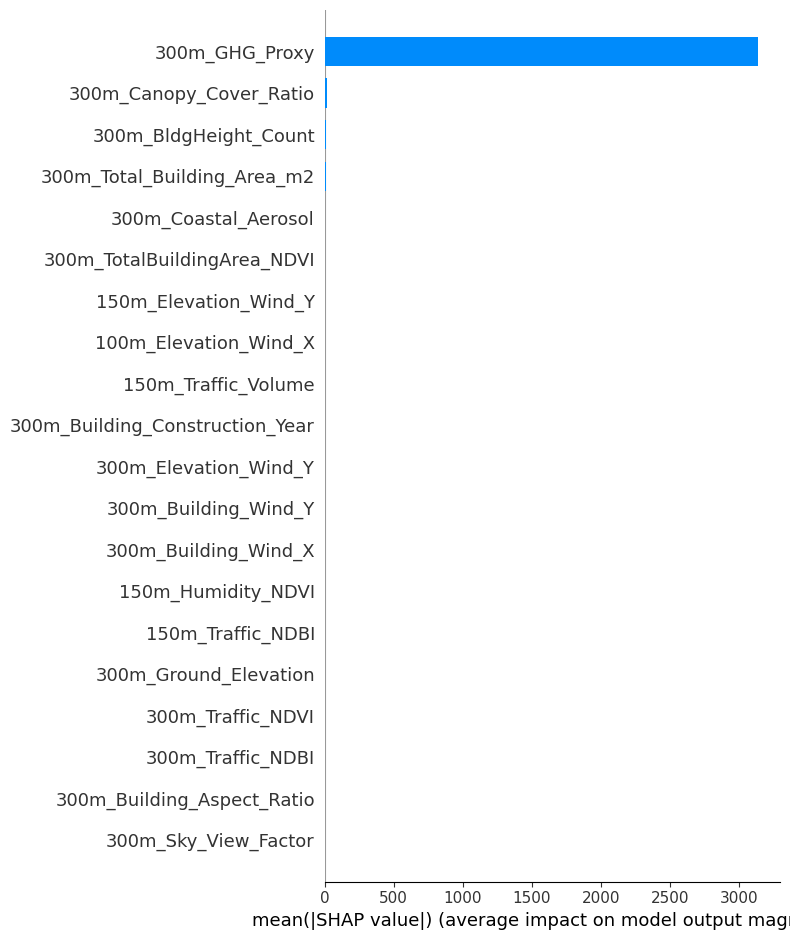

In [16]:
explainer.bar_plot()

>TODO

## Dependence Plot

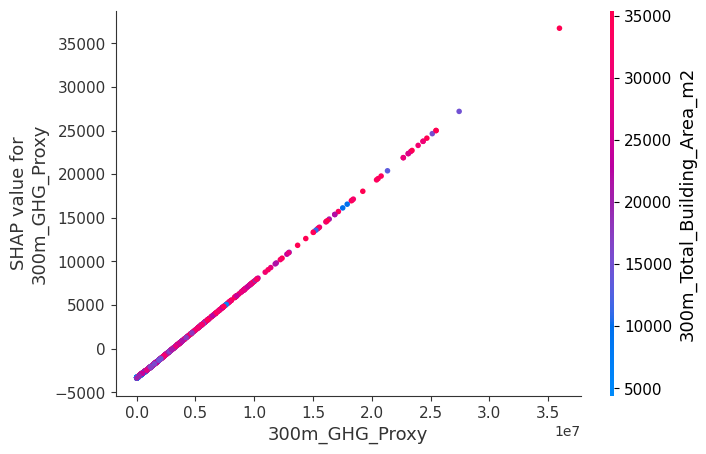

In [17]:
explainer.dependence_plot("300m_GHG_Proxy") #TODO change the var

>TODO

## Force Plot

Finally, we will explain an individual prediction. We can do this one by one for all predictions, but for now we will do the first one.

In [18]:
#location index
record_index = 0

In [19]:
#show location
submission_df.iloc[record_index, :]

,0
Longitude,-73.971665
Latitude,40.788763
UHI Index,0.962562


In [22]:
explainer.shap_values

array([[-2.96366673e-05,  6.53094280e-02,  1.86053301e-02, ...,
        -9.72433953e-05,  5.43797112e+00,  3.33990886e+03],
       [-2.08136488e-05,  6.77941718e-02,  1.80585862e-02, ...,
        -1.08607884e-04,  5.07122815e+00,  3.06686021e+03],
       [-8.60277971e-06,  1.44468881e-02, -1.20883137e-01, ...,
         1.81601246e-05, -8.68326827e+00, -3.36415621e+03],
       ...,
       [ 7.87772739e-07, -4.92417031e-01, -1.18674215e-01, ...,
         6.73334519e-05, -2.03875780e+01, -2.77386114e+03],
       [ 2.82565571e-05,  3.51368608e-02,  3.73888527e-02, ...,
        -1.20317266e-04,  3.16306246e+00,  1.94513331e+03],
       [ 1.32515045e-05,  1.44348357e-01, -1.40205578e-01, ...,
         2.46280439e-05, -1.93831367e+01, -2.82020268e+03]])

In [33]:
# For multi-output models
expected_values = [ev.numpy() for ev in explainer.explainer.expected_value]
print(expected_values)



[3374.3533]


In [27]:
shap.initjs()
# Convert SHAP values and test sample to NumPy
shap_values_np = np.array(explainer.shap_values)  # Ensure it's a NumPy array
test_sample_np = np.array(test_dataset.iloc[0, :])  # Convert first row of DataFrame to NumPy

# Ensure expected_value is a single value (not tensor)
expected_value_np = np.array(explainer.explainer.expected_value)

# Now call force_plot
shap.force_plot(expected_value_np, explainer.shap_values[0, :], test_dataset.values[0,:], feature_names=test_dataset.columns)

In [21]:
shap.initjs()
explainer.force_plot(index=record_index)

TypeError: Object of type EagerTensor is not JSON serializable

>TODO

# Summary Table

In [ ]:
# create the summary table
models = ['mixed_buffers_RandomForestRegressor_model']

data = {
    'Model': models,
    'Training R-squared': [insample_r2],
    'Validation R-squared': [outsample_r2]
}

summary_df = pd.DataFrame(data)
summary_df

# Save The Model

Now we will save both the model and the scaler.

In [20]:
# Save the best model
resnet_model.save("mixed_buffers_ResNet_model.keras")

# Save the scaler
with open('mixed_buffers_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Conclusion

>TODO

# NOTES

- Using the features selected by Random forest does better than doing feature selectio using my ResNet model
- Using smaller neaurons in my first later gave me a worse score, so I had to increase it. Meaning Increasing the neuron count helped capture more detailed patterns in the data.
- ResNet helped in making my neural network better.
- Using Adaptive Learning Rate helped in making my neural network better
- The mixed buffer dataset improved my Random Forest model
- Also using the mixed buffer dataset helped improve my neural network model
- the neural network with variables from...
   - v1 mixed buffer dataset got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
   - v2 mixed buffer dataset that were RFECV selected got a 0.63 in out-sample and a 0.84 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 1)...
      - got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
      - got a 0.78 in out-sample and 0.95 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 2)...
      - got a 0.95 in out-sample and 0.96 in in-sample (ORIGINAL model)
      - got a 0.79 in out-sample and 0.96 in in-sample (model fine tuned for energy vars)
- v1 mixed buffer dataset with ORIGINAL model is the best, less overfitting